In [1]:
import pickle
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib import rc
import numpy as np

In [2]:
def print_network_graph(ssoln_dict:dict, eps:float=0.0, norm_factor:float=1.0):
    G = nx.DiGraph()
    # ssoln_dict = iter_ssoln_dict[1]
    nodes = {
    'Location 1': {
        'Capacity': ssoln_dict['Cap_P[loc1,com1_process,0]']/norm_factor if 'Cap_P[loc1,com1_process,0]' in ssoln_dict.keys() else 0,
        'Inventory': ssoln_dict['Cap_S[loc1,com1_store_com1_in_stored,0]']/norm_factor if 'Cap_S[loc1,com1_store_com1_in_stored,0]' in ssoln_dict.keys() else 0
    },
    'Location 2': {
        'Capacity': ssoln_dict['Cap_P[loc2,com1_process,0]']/norm_factor if 'Cap_P[loc2,com1_process,0]' in ssoln_dict.keys() else 0,
        'Inventory': ssoln_dict['Cap_S[loc2,com1_store_com1_in_stored,0]']/norm_factor if 'Cap_S[loc2,com1_store_com1_in_stored,0]' in ssoln_dict.keys() else 0
    },
    'Location 3': {
        'Capacity': ssoln_dict['Cap_P[loc3,com1_process,0]']/norm_factor if 'Cap_P[loc3,com1_process,0]' in ssoln_dict.keys() else 0,
        'Inventory': ssoln_dict['Cap_S[loc3,com1_store_com1_in_stored,0]']/norm_factor if 'Cap_S[loc3,com1_store_com1_in_stored,0]' in ssoln_dict.keys() else 0
    },
    'Location 4': {
        'Capacity': ssoln_dict['Cap_P[loc4,com1_process,0]']/norm_factor if 'Cap_P[loc4,com1_process,0]' in ssoln_dict.keys() else 0,
        'Inventory': ssoln_dict['Cap_S[loc4,com1_store_com1_in_stored,0]']/norm_factor if 'Cap_S[loc4,com1_store_com1_in_stored,0]' in ssoln_dict.keys() else 0
    },
    'Location 5': {
        'Capacity': ssoln_dict['Cap_P[loc5,com1_process,0]']/norm_factor if 'Cap_P[loc5,com1_process,0]' in ssoln_dict.keys() else 0,
        'Inventory': ssoln_dict['Cap_S[loc5,com1_store_com1_in_stored,0]']/norm_factor if 'Cap_S[loc5,com1_store_com1_in_stored,0]' in ssoln_dict.keys() else 0
    },
    'Location 6': {
        'Capacity': ssoln_dict['Cap_P[loc6,com1_process,0]']/norm_factor if 'Cap_P[loc6,com1_process,0]' in ssoln_dict.keys() else 0,
        'Inventory': ssoln_dict['Cap_S[loc6,com1_store_com1_in_stored,0]']/norm_factor if 'Cap_S[loc6,com1_store_com1_in_stored,0]' in ssoln_dict.keys() else 0
    },
    'Location 7': {
        'Capacity': ssoln_dict['Cap_P[loc7,com1_process,0]']/norm_factor if 'Cap_P[loc7,com1_process,0]' in ssoln_dict.keys() else 0,
        'Inventory': ssoln_dict['Cap_S[loc7,com1_store_com1_in_stored,0]']/norm_factor if 'Cap_S[loc7,com1_store_com1_in_stored,0]' in ssoln_dict.keys() else 0
    },
    }
    
    # Add nodes to the graph
    G.add_nodes_from(nodes.keys())
    
    # Define edges (connections between nodes)
    edges = [
        ('Location 1', 'Location 2', {'weight': ssoln_dict['Cap_F[loc1,loc2,truck12,0]']/norm_factor if 'Cap_F[loc1,loc2,truck12,0]' in ssoln_dict.keys() else 0}),
        ('Location 1', 'Location 3', {'weight': ssoln_dict['Cap_F[loc1,loc3,truck13,0]']/norm_factor if 'Cap_F[loc1,loc3,truck13,0]' in ssoln_dict.keys() else 0}),
        ('Location 1', 'Location 5', {'weight': ssoln_dict['Cap_F[loc1,loc5,plane15,0]']/norm_factor if 'Cap_F[loc1,loc5,plane15,0]' in ssoln_dict.keys() else 0}),
        ('Location 2', 'Location 4', {'weight': ssoln_dict['Cap_F[loc2,loc4,truck24,0]']/norm_factor if 'Cap_F[loc2,loc4,truck24,0]' in ssoln_dict.keys() else 0}),
        ('Location 2', 'Location 5', {'weight': ssoln_dict['Cap_F[loc2,loc5,truck25,0]']/norm_factor if 'Cap_F[loc2,loc5,truck25,0]' in ssoln_dict.keys() else 0}),
        ('Location 3', 'Location 4', {'weight': ssoln_dict['Cap_F[loc3,loc4,truck34,0]']/norm_factor if 'Cap_F[loc3,loc4,truck34,0]' in ssoln_dict.keys() else 0}),
        ('Location 4', 'Location 5', {'weight': ssoln_dict['Cap_F[loc4,loc5,truck45,0]']/norm_factor if 'Cap_F[loc4,loc5,truck45,0]' in ssoln_dict.keys() else 0}),
        ('Location 4', 'Location 7', {'weight': ssoln_dict['Cap_F[loc4,loc7,truck47,0]']/norm_factor if 'Cap_F[loc4,loc7,truck47,0]' in ssoln_dict.keys() else 0}),
        ('Location 6', 'Location 4', {'weight': ssoln_dict['Cap_F[loc6,loc4,truck64,0]']/norm_factor if 'Cap_F[loc6,loc4,truck64,0]' in ssoln_dict.keys() else 0}),
        # ('Location 6', 'Location 5', {'weight': ssoln_dict['Cap_F[loc6,loc5,plane65,0]'] if 'Cap_F[loc6,loc5,plane65,0]' in ssoln_dict.keys() else 0}),
        ('Location 7', 'Location 5', {'weight': ssoln_dict['Cap_F[loc7,loc5,truck75,0]']/norm_factor if 'Cap_F[loc7,loc5,truck75,0]' in ssoln_dict.keys() else 0}),
    ]
    
    # Add edges to the graph
    G.add_edges_from(edges)
    
    # Define fixed positions for nodes
    fixed_positions = {
        'Location 1': (-2, 2),
        'Location 2': (0, 2),
        'Location 3': (-2, 0),
        'Location 4': (0, 0),
        'Location 5': (2, 0),
        'Location 6': (-2, -2),
        'Location 7': (1, -2)
    }
    
    # Create custom labels combining multiple pieces of information
    node_labels = {node: f"Capacity: {data['Capacity']:.2f}\nInventory: {data['Inventory']:.2f}" for node, data in nodes.items()}
    
    # Draw nodes and edges with fixed positions
    nx.draw_networkx_nodes(G, fixed_positions, node_color='skyblue', node_size=700)
    nx.draw_networkx_edges(G, fixed_positions, edgelist=edges, arrowstyle='simple', arrowsize=15)
    nx.draw_networkx_labels(G, fixed_positions, labels=node_labels, font_size=8, font_color='red', bbox=dict(facecolor="white", edgecolor="none", alpha=0.7, boxstyle="round,pad=0.3"))
    
    # Draw edge labels (optional)
    edge_labels = {(u, v): round(d['weight'],3) for u, v, d in G.edges(data=True)}
    nx.draw_networkx_edge_labels(G, fixed_positions, edge_labels=edge_labels, label_pos=0.4, font_size=8)
    
    # Expand plot limits to prevent cutoff
    x_values, y_values = zip(*fixed_positions.values())
    plt.xlim(min(x_values) - 1, max(x_values) + 1)
    plt.ylim(min(y_values) - 1, max(y_values) + 1)
    
    # Show the plot
    plt.title(f"Supply Chain Network considering fill rate of {eps}")
    # plt.figure(figsize=(16,12))
    plt.show()  

In [3]:
# eps=1

In [4]:
# with open(f'HPRC_Results/ssoln_64_{int(eps * 10):02d}_Backlog.pkl', 'rb') as file:
#     load_ssoln = pickle.load(file)

In [5]:
# print_network_graph(ssoln_dict=load_ssoln, eps=eps, norm_factor=1)

In [6]:
eps=0.0

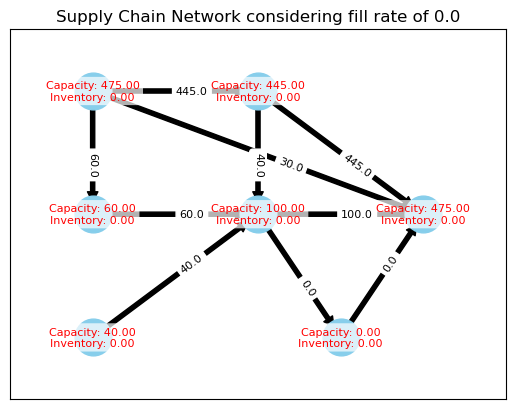

Procurement capacity at Location 1: 475.0
Procurement capacity at Location 6: 40.0


In [7]:
with open(f'ncl/ssoln_32_{int(eps * 10):02d}_Backlog_ncl.pkl', 'rb') as file:
        load_ssoln_ncl = pickle.load(file)
print_network_graph(ssoln_dict=load_ssoln_ncl, eps=eps, norm_factor=1)
print(f'Procurement capacity at Location 1: {load_ssoln_ncl["Cap_P[loc1,procure com1,0]"]}')
print(f'Procurement capacity at Location 6: {load_ssoln_ncl["Cap_P[loc6,procure com1,0]"]}')

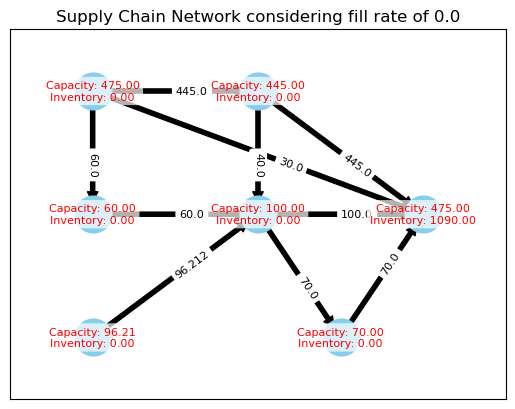

Procurement capacity at Location 1: 475.0
Procurement capacity at Location 6: 96.21212121212122


In [8]:
with open(f'cl/ssoln_128_{int(eps * 10):02d}_Backlog_cl.pkl', 'rb') as file:
        load_ssoln_cl = pickle.load(file)
print_network_graph(ssoln_dict=load_ssoln_cl, eps=eps, norm_factor=1)
print(f'Procurement capacity at Location 1: {load_ssoln_cl["Cap_P[loc1,procure com1,0]"]}')
print(f'Procurement capacity at Location 6: {load_ssoln_cl["Cap_P[loc6,procure com1,0]"]}')

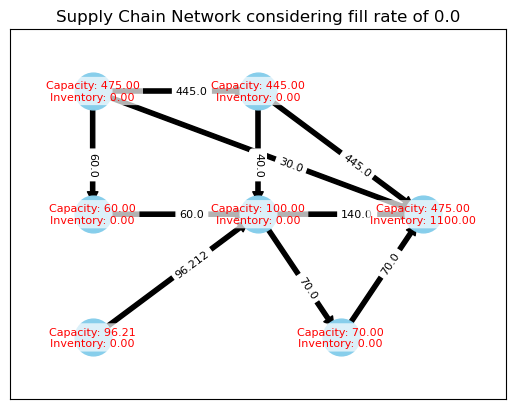

Procurement capacity at Location 1: 475.0
Procurement capacity at Location 6: 96.21212121212011


In [9]:
with open(f'cl_step2/ssoln_256_{int(eps * 10):02d}_Backlog_cl_step2.pkl', 'rb') as file:
        load_ssoln_cl = pickle.load(file)
print_network_graph(ssoln_dict=load_ssoln_cl, eps=eps, norm_factor=1)
print(f'Procurement capacity at Location 1: {load_ssoln_cl["Cap_P[loc1,procure com1,0]"]}')
print(f'Procurement capacity at Location 6: {load_ssoln_cl["Cap_P[loc6,procure com1,0]"]}')

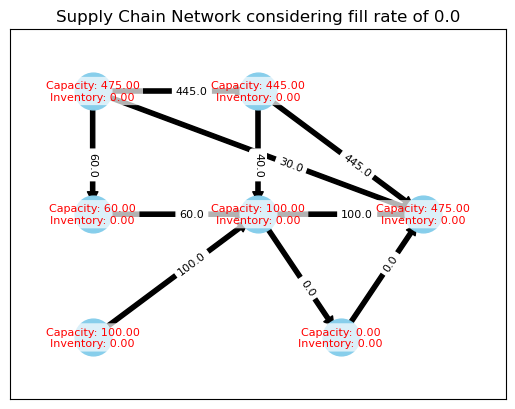

Procurement capacity at Location 1: 475.0
Procurement capacity at Location 6: 100.00000000000006


In [10]:
with open(f'bayesian/ssoln_32_{int(eps * 10):02d}_Backlog_bayesian_ncl.pkl', 'rb') as file:
        load_ssoln_bayesian_ncl = pickle.load(file)
print_network_graph(ssoln_dict=load_ssoln_bayesian_ncl, eps=eps, norm_factor=1)
print(f'Procurement capacity at Location 1: {load_ssoln_bayesian_ncl["Cap_P[loc1,procure com1,0]"]}')
print(f'Procurement capacity at Location 6: {load_ssoln_bayesian_ncl["Cap_P[loc6,procure com1,0]"]}')

In [11]:
with open(f'ncl/results_32_{int(eps * 10):02d}_Backlog_ncl.pkl', 'rb') as file:
        results_ncl = pickle.load(file)

In [12]:
results_ncl

{'Expected Cost UI': 629527.9872,
 'First Stage Cost': 79405.0,
 'Total Expected Penalty Cost': 720.0,
 'Total Expected Backlog Cost': 174750.0,
 'Execution Time': 1987.4764833450317}

In [13]:
with open(f'cl/results_128_{int(eps * 10):02d}_Backlog_cl.pkl', 'rb') as file:
        results_cl = pickle.load(file)

In [14]:
results_cl

{'Expected Cost UI': 746436.0767314209,
 'First Stage Cost': 145551.86432506886,
 'Total Expected Penalty Cost': 728.39772,
 'Total Expected Backlog Cost': 185664.912,
 'Execution Time': 11913.160253763199}

In [15]:
(results_cl['First Stage Cost'] - results_ncl['First Stage Cost'])/results_ncl['First Stage Cost']

0.8330314756636089

In [16]:
# for eps in [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]:
#     with open(f'ssoln_32_{int(eps * 10):02d}_Backlog_ncl.pkl', 'rb') as file:
#         load_ssoln = pickle.load(file)
#     print_network_graph(ssoln_dict=load_ssoln, eps=eps, norm_factor=1)
#     print(f'Procurement capacity at Location 1: {load_ssoln["Cap_P[loc1,procure com1,0]"]}')
#     print(f'Procurement capacity at Location 6: {load_ssoln["Cap_P[loc6,procure com1,0]"]}')

In [17]:
# rc('font', **{'family': 'serif', 'size': 14})
# 
# fig, ax = plt.subplots(figsize = (8, 6))
# # ax1 = ax.twinx()
# 
# x, y = list(), list()
# for eps in [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]:
#     x.append(eps)
#     with open(f'HPRC_results/results_64_{int(eps * 10):02d}_Backlog.pkl', 'rb') as file:
#         load_results = pickle.load(file)
#     y.append(load_results['Expected Cost UI'])
# # Example data
# # x = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
# # y = [414840.2028, 414840.2028, 425383.94, 435927.6931, 446471.4384, 457015.1836]
# y2 = [25594, 25594, 29495, 3396, 37297, 41198]
# # Plotting
# ax.plot(x, y, marker='o', label='ef_obj', color = 'green', linewidth=3, markersize=10)  # 'o' adds circular markers at data points
# # ax1.plot(x, y2, marker='x', label='approx_obj', color ='blue')
# plt.title('Expected Cost - Extensive Form')
# ax.set_ylabel('Expected Cost')
# # ax1.set_ylabel('Expected Cost (Approx.)')
# ax.set_xlabel('Fill rate')
# plt.grid(alpha = 0.3)
# # ax1.legend(loc='lower right')
# ax.legend(loc='upper left')
# plt.tight_layout()
# plt.savefig(fname = 'pareto_ef', dpi = 300)
# plt.show()
# plt.rcdefaults()

In [18]:
# with open (f'cl/backlog_scen_dict_cl.pkl','rb') as file:
#     load_cl_scen_dict = pickle.load(file)

In [19]:
# with open (f'ncl/backlog_scen_dict_ncl.pkl','rb') as file:
#     load_ncl_scen_dict = pickle.load(file)

In [20]:
# load_cl_scen_dict.keys()

In [21]:
# load_ncl_scen_dict.keys()

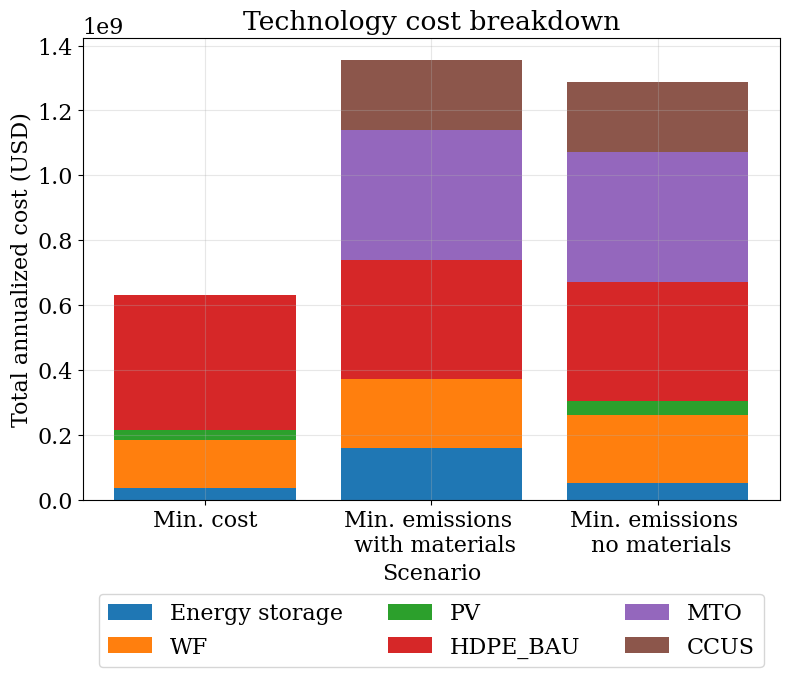

In [22]:
# Your data
data = [
[36827954.72, 158734568.76, 52062285.51], #Storage
[148079726.38, 214234032.19, 209334703.82], #WF
[30790530.75, 0, 43527407.78], #PV
[414662835.19, 365402608.54, 365402608.45], #BAU
[0, 402756878.33, 402756877.75], #MTO
[0, 215206686.07999998, 215206686.07999998], #CCUS
] 

# Transpose the data for plotting
data_transposed = np.array(data)

# Create stacked bar plot
rc('font', **{'family': 'serif',
           'serif': ['Computer Modern'], 'size': 16})
fig, ax = plt.subplots(figsize = (9,6))
bars = ax.bar(np.arange(len(data[0])), data_transposed[0], label='Energy storage')
labels = ['WF', 'PV', 'HDPE_BAU', 'MTO','CCUS']
for i in range(1, len(data)):
    bars = ax.bar(np.arange(len(data[0])), data_transposed[i], bottom=np.sum(data_transposed[:i], axis=0), label=labels[i-1])

# Add labels, title, and legend
ax.set_xlabel('Scenario')
ax.set_ylabel('Total annualized cost (USD)')
ax.set_title('Technology cost breakdown')

xtick_positions = np.arange(len(data[0]))
xtick_labels = ['Min. cost', 'Min. emissions \n with materials', 'Min. emissions \n no materials']
ax.set_xticks(xtick_positions)
ax.set_xticklabels(xtick_labels)

ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.18), ncol=3)
plt.grid(zorder=0, alpha = 0.3)
plt.rcdefaults()

# Show the plot
plt.show()

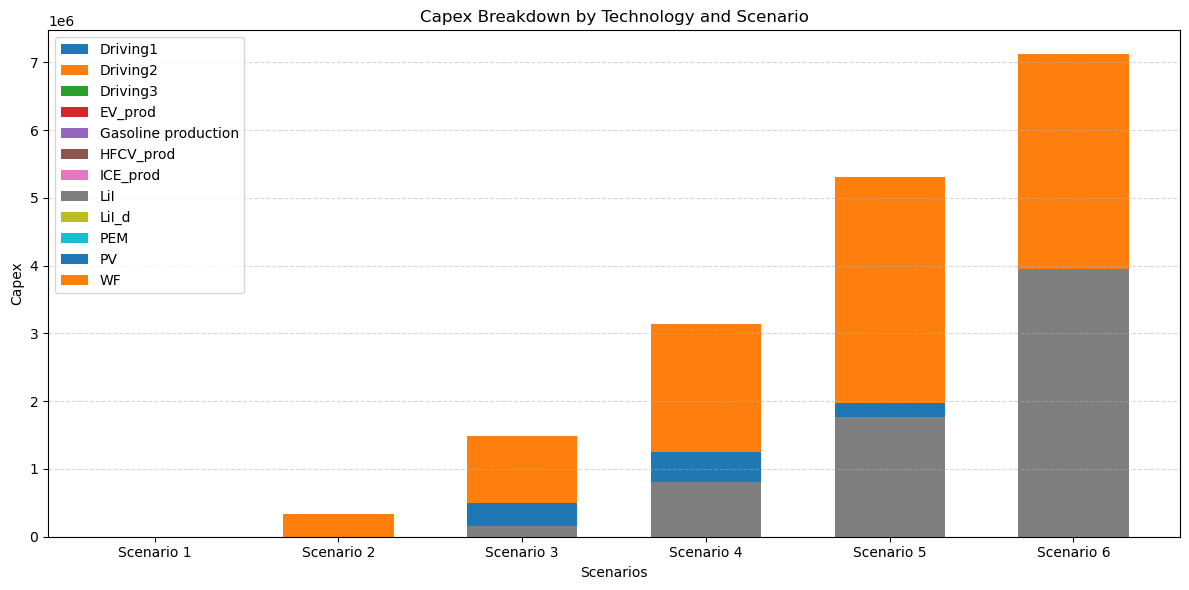

In [23]:
# Initialize technologies and capex data
technologies = [('HO', 'Driving1', 0), ('HO', 'Driving2', 0), ('HO', 'Driving3', 0),
                ('HO', 'EV_prod', 0), ('HO', 'Gasoline production', 0),
                ('HO', 'HFCV_prod', 0), ('HO', 'ICE_prod', 0), ('HO', 'LiI', 0),
                ('HO', 'LiI_d', 0), ('HO', 'PEM', 0), ('HO', 'PV', 0),
                ('HO', 'WF', 0)]

# Capex data (example, replace this with your actual data)
capex_data = [
    {('HO', 'Driving1'): 0.0, ('HO', 'Driving2'): 0.0, ('HO', 'Driving3'): 0.0,
     ('HO', 'EV_prod'): 0.0, ('HO', 'Gasoline production'): 0.0,
     ('HO', 'HFCV_prod'): 0.0, ('HO', 'ICE_prod'): 0.0, ('HO', 'LiI'): 0.0,
     ('HO', 'LiI_d'): 0.0, ('HO', 'PEM'): 0.0, ('HO', 'PV'): 0.0,
     ('HO', 'WF'): 0.0},
    {('HO', 'Driving1'): 0.0, ('HO', 'Driving2'): 0.0, ('HO', 'Driving3'): 0.0,
     ('HO', 'EV_prod'): 0.0, ('HO', 'Gasoline production'): 0.0,
     ('HO', 'HFCV_prod'): 0.0, ('HO', 'ICE_prod'): 0.0, ('HO', 'LiI'): 0.0,
     ('HO', 'LiI_d'): 0.0, ('HO', 'PEM'): 0.0, ('HO', 'PV'): 0.0,
     ('HO', 'WF'): 335842.5566191988},
    {('HO', 'Driving1'): 0.0, ('HO', 'Driving2'): 0.0, ('HO', 'Driving3'): 0.0,
     ('HO', 'EV_prod'): 0.0, ('HO', 'Gasoline production'): 0.0,
     ('HO', 'HFCV_prod'): 0.0, ('HO', 'ICE_prod'): 0.0, ('HO', 'LiI'): 162203.35236218787,
     ('HO', 'LiI_d'): 0.0, ('HO', 'PEM'): 0.0, ('HO', 'PV'): 341488.63966309716,
     ('HO', 'WF'): 977833.8151999465},
    {('HO', 'Driving1'): 0.0, ('HO', 'Driving2'): 0.0, ('HO', 'Driving3'): 0.0,
     ('HO', 'EV_prod'): 0.0, ('HO', 'Gasoline production'): 0.0,
     ('HO', 'HFCV_prod'): 0.0, ('HO', 'ICE_prod'): 0.0, ('HO', 'LiI'): 814381.8026258291,
     ('HO', 'LiI_d'): 0.0, ('HO', 'PEM'): 0.0, ('HO', 'PV'): 439470.26834187517,
     ('HO', 'WF'): 1882113.1042218911},
    {('HO', 'Driving1'): 0.0, ('HO', 'Driving2'): 0.0, ('HO', 'Driving3'): 0.0,
     ('HO', 'EV_prod'): 0.0, ('HO', 'Gasoline production'): 0.0,
     ('HO', 'HFCV_prod'): 0.0, ('HO', 'ICE_prod'): 0.0, ('HO', 'LiI'): 1770789.0394942726,
     ('HO', 'LiI_d'): 0.0, ('HO', 'PEM'): 0.0, ('HO', 'PV'): 207876.77348638972,
     ('HO', 'WF'): 3333712.8110114653},
    {('HO', 'Driving1'): 0.0, ('HO', 'Driving2'): 0.0, ('HO', 'Driving3'): 0.0,
     ('HO', 'EV_prod'): 0.0, ('HO', 'Gasoline production'): 0.0,
     ('HO', 'HFCV_prod'): 0.0, ('HO', 'ICE_prod'): 0.0, ('HO', 'LiI'): 3951409.887033983,
     ('HO', 'LiI_d'): 0.0, ('HO', 'PEM'): 0.0, ('HO', 'PV'): 0.0,
     ('HO', 'WF'): 3166282.786141873}
]

# Initialize a dictionary to store Capex values for each technology per scenario
capex_by_tech = {tech[1]: [0] * 6 for tech in technologies}  # tech[1] is the technology name (e.g., 'Driving1')

# Extract Capex values for each technology per scenario
for i in range(6):  # Loop over each scenario
    for tech in technologies:
        tech_name = tech[1]  # Extract technology name (e.g., 'EV_prod')
        
        # Check if tech_name exists in the current scenario's Capex data
        tech_key = ('HO', tech_name)  # Create the key to search in capex_data
        if tech_key in capex_data[i]:
            capex_value = capex_data[i][tech_key]
        else:
            capex_value = 0  # If the technology doesn't have a Capex value in this scenario
        
        capex_by_tech[tech_name][i] = capex_value  # Store Capex value for the technology in the respective scenario

# === Prepare data for plotting ===
fig, ax = plt.subplots(figsize=(12, 6))

bar_width = 0.6
x = range(6)

# Create a stacked bar plot with all technologies, including those with zero values
bottoms = [0] * 6  # Start with all bottoms at zero for stacking
for tech, capex_values in capex_by_tech.items():
    # Only plot technologies with non-zero values
    ax.bar(x, capex_values, label=tech, width=bar_width, bottom=bottoms)
    bottoms = [bottoms[i] + capex_values[i] for i in x]  # Update bottoms for stacking

ax.set_xlabel("Scenarios")
ax.set_ylabel("Capex")
ax.set_title("Capex Breakdown by Technology and Scenario")
ax.set_xticks(x)
ax.set_xticklabels([f"Scenario {i+1}" for i in x])
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()